<a href="https://colab.research.google.com/github/lekkku/UTS/blob/main/jawaban_p5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [18]:
print("testcpns.csv ...")

testcpns.csv ...


In [19]:
df = pd.read_csv('testcpns.csv')
df['ipk'] = df['ipk'].astype(str).str.replace(',', '.').astype(float)
df['status'] = df['diterima'].map({0: 'Tidak Diterima', 1: 'Diterima'})

In [20]:
print("Data berhasil dimuat!")
print(f"   Jumlah data : {len(df)} baris")
print(f"   Kolom       : {list(df.columns)}")

Data berhasil dimuat!
   Jumlah data : 40 baris
   Kolom       : ['toefl', 'ipk', 'pengalaman_kerja', 'diterima', 'status']


ringkasan data

In [21]:
print("\n" + "="*55)
print("  (a) RINGKASAN STATISTIK DATA")
print("="*55)
print(df[['toefl', 'ipk', 'pengalaman_kerja', 'diterima']].describe().round(2))

print(f"  Jumlah Diterima     : {df['diterima'].sum()} orang")
print(f"  Jumlah Tidak Diterima: {(df['diterima']==0).sum()} orang")


  (a) RINGKASAN STATISTIK DATA
        toefl    ipk  pengalaman_kerja  diterima
count   40.00  40.00             40.00     40.00
mean   654.00   2.69              3.42      0.48
std     61.43   0.65              1.74      0.51
min    540.00   1.07              1.00      0.00
25%    607.50   2.07              2.00      0.00
50%    660.00   3.03              4.00      0.00
75%    690.00   3.07              5.00      1.00
max    780.00   4.00              6.00      1.00
  Jumlah Diterima     : 19 orang
  Jumlah Tidak Diterima: 21 orang


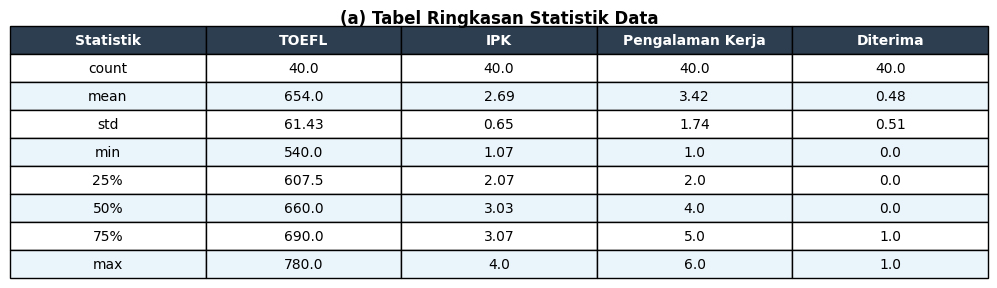

In [22]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
desc = df[['toefl','ipk','pengalaman_kerja','diterima']].describe().round(2)
rows = [[idx] + list(row) for idx, row in zip(desc.index, desc.values)]
header = ['Statistik', 'TOEFL', 'IPK', 'Pengalaman Kerja', 'Diterima']
tbl = ax.table(cellText=rows, colLabels=header, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for j in range(len(header)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rows)+1):
    c = '#eaf4fb' if i % 2 == 0 else 'white'
    for j in range(len(header)):
        tbl[i, j].set_facecolor(c)
ax.set_title('(a) Tabel Ringkasan Statistik Data', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

scatter


  (b) SCATTER PLOT DATA


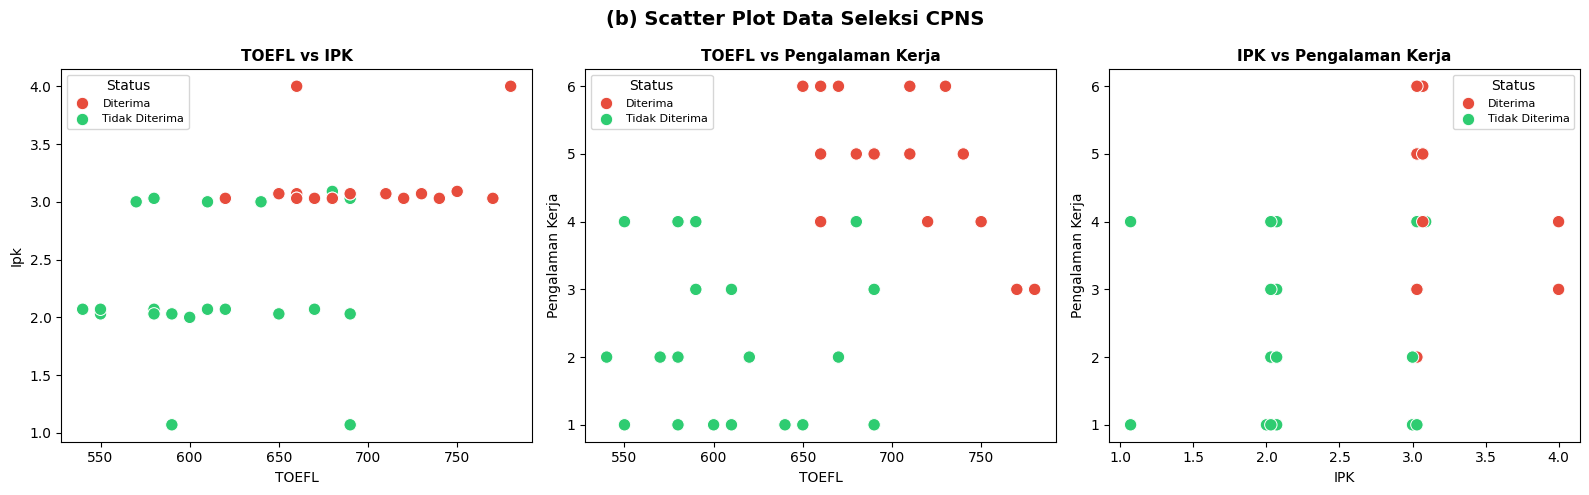

In [23]:
print("\n" + "="*55)
print("  (b) SCATTER PLOT DATA")
print("="*55)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('(b) Scatter Plot Data Seleksi CPNS', fontsize=14, fontweight='bold')

combos = [('toefl','ipk'), ('toefl','pengalaman_kerja'), ('ipk','pengalaman_kerja')]
titles = ['TOEFL vs IPK', 'TOEFL vs Pengalaman Kerja', 'IPK vs Pengalaman Kerja']

for i, (x_col, y_col) in enumerate(combos):
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='status',
                    palette=['#e74c3c','#2ecc71'], s=80, ax=axes[i])
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel(x_col.upper())
    axes[i].set_ylabel(y_col.replace('_',' ').title())
    axes[i].legend(title='Status', fontsize=8)

plt.tight_layout()
plt.show()

visualisasi

  (c) VISUALISASI DISTRIBUSI DATA


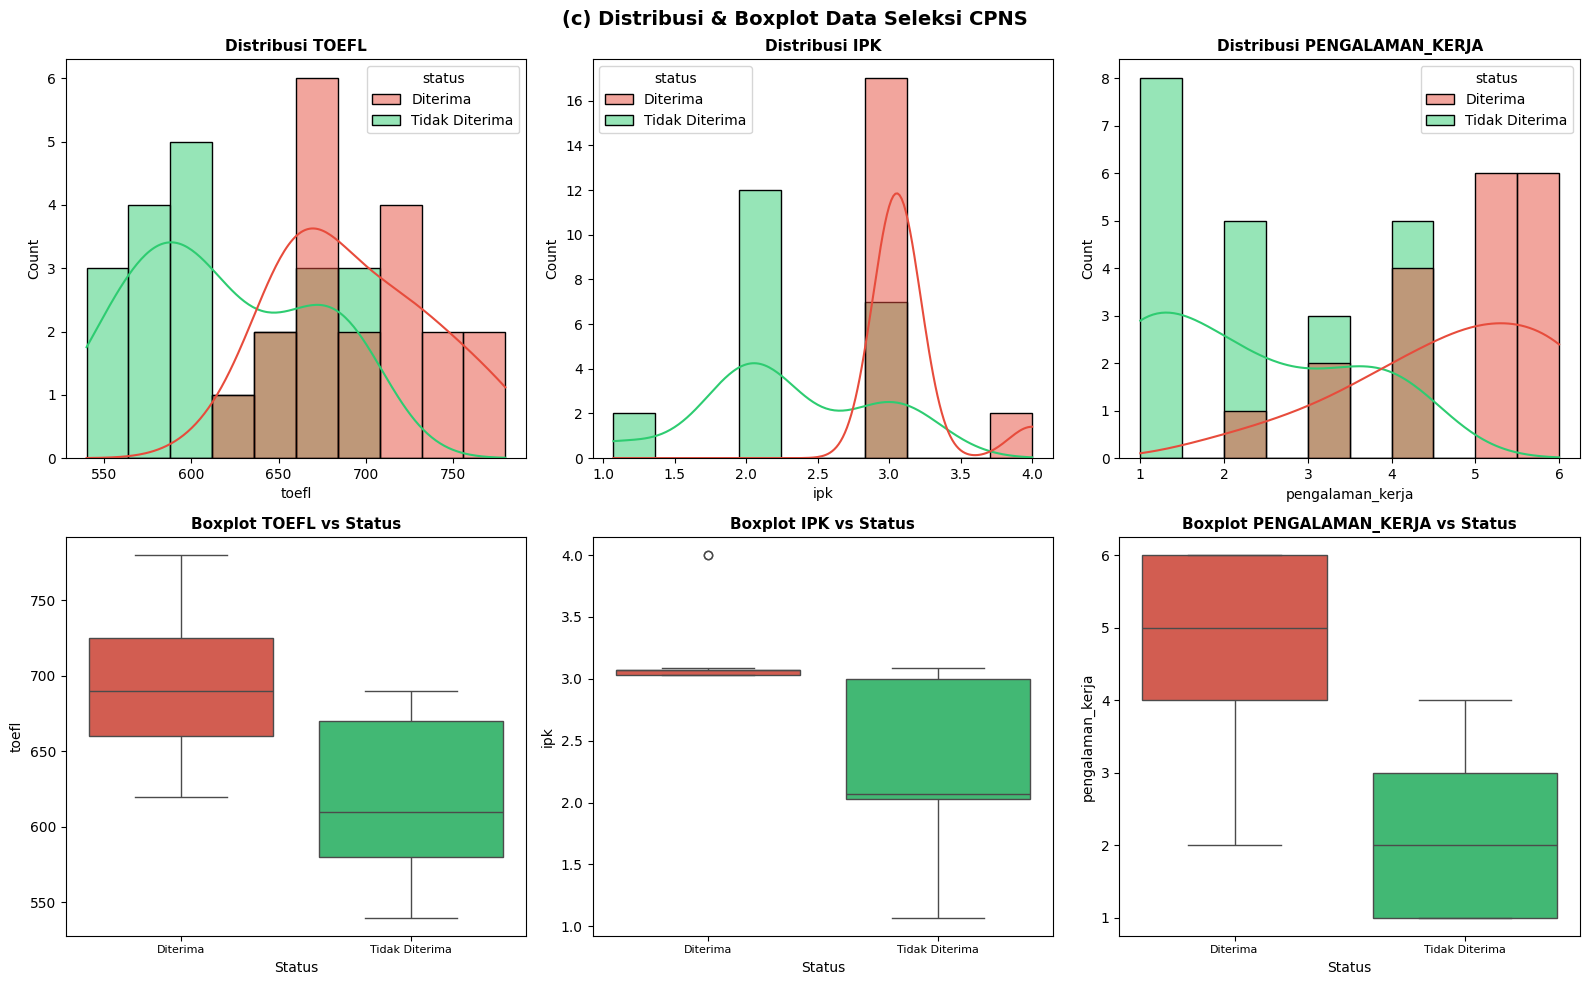

In [24]:
print("="*55)
print("  (c) VISUALISASI DISTRIBUSI DATA")
print("="*55)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('(c) Distribusi & Boxplot Data Seleksi CPNS', fontsize=14, fontweight='bold')

for i, col in enumerate(['toefl', 'ipk', 'pengalaman_kerja']):
    # Histogram
    sns.histplot(data=df, x=col, hue='status',
                 palette=['#e74c3c','#2ecc71'], kde=True, bins=10, ax=axes[0][i])
    axes[0][i].set_title(f'Distribusi {col.upper()}', fontsize=11, fontweight='bold')

    # Boxplot
    sns.boxplot(data=df, x='status', y=col,
                palette=['#e74c3c','#2ecc71'], ax=axes[1][i])
    axes[1][i].set_title(f'Boxplot {col.upper()} vs Status', fontsize=11, fontweight='bold')
    axes[1][i].set_xlabel('Status')
    axes[1][i].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

matrix

  (d) CONFUSION MATRIX
  Confusion Matrix:
[[6 1]
 [0 3]]

  Accuracy Model : 90.0%


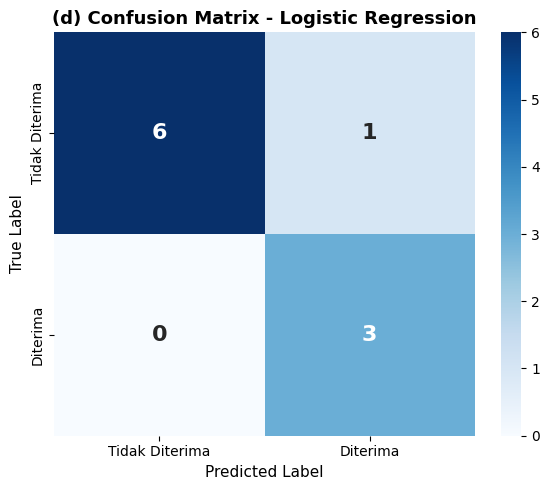

In [25]:
print("="*55)
print("  (d) CONFUSION MATRIX")
print("="*55)

# Siapkan fitur dan target
X = df[['toefl', 'ipk', 'pengalaman_kerja']]
y = df['diterima']

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data train-test (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# Latih model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"  Confusion Matrix:\n{cm}")
print(f"\n  Accuracy Model : {accuracy*100:.1f}%")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Diterima', 'Diterima'],
            yticklabels=['Tidak Diterima', 'Diterima'],
            ax=ax, annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('(d) Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
print("="*55)
print("  (e) CLASSIFICATION REPORT")
print("="*55)

print(classification_report(y_test, y_pred,
      target_names=['Tidak Diterima', 'Diterima']))

  (e) CLASSIFICATION REPORT
                precision    recall  f1-score   support

Tidak Diterima       1.00      0.86      0.92         7
      Diterima       0.75      1.00      0.86         3

      accuracy                           0.90        10
     macro avg       0.88      0.93      0.89        10
  weighted avg       0.93      0.90      0.90        10



Prediksi pelamar baru


In [27]:
print("="*55)
print("  (f) PREDIKSI PELAMAR BARU")
print("="*55)

# Data pelamar baru (bisa diubah sesuai kebutuhan)
new_applicants = pd.DataFrame({
    'toefl': [700, 580, 720],
    'ipk': [3.50, 2.10, 3.80],
    'pengalaman_kerja': [4, 1, 5]
})

new_scaled = scaler.transform(new_applicants)
predictions = model.predict(new_scaled)
probabilities = model.predict_proba(new_scaled)

result = new_applicants.copy()
result['Prediksi'] = ['DITERIMA ✓' if p == 1 else 'TIDAK DITERIMA ✗' for p in predictions]
result['Probabilitas Diterima'] = [f"{p[1]*100:.1f}%" for p in probabilities]
result.columns = ['TOEFL', 'IPK', 'Pengalaman Kerja', 'Prediksi', 'Prob. Diterima']

print(result.to_string(index=False))

  (f) PREDIKSI PELAMAR BARU
 TOEFL  IPK  Pengalaman Kerja         Prediksi Prob. Diterima
   700  3.5                 4       DITERIMA ✓          89.9%
   580  2.1                 1 TIDAK DITERIMA ✗           2.2%
   720  3.8                 5       DITERIMA ✓          97.5%


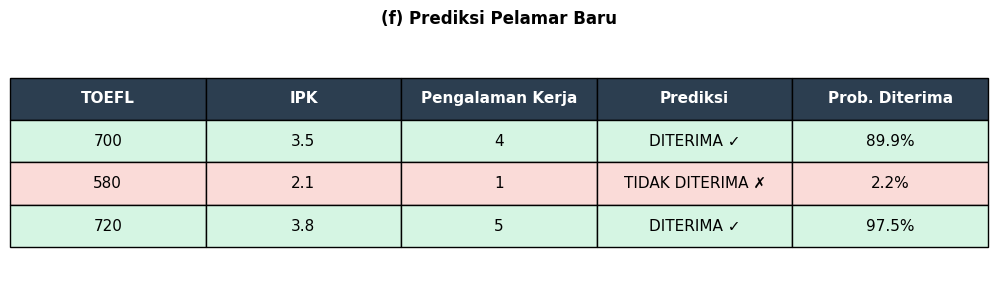

In [28]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl3 = ax.table(
    cellText=result.values,
    colLabels=result.columns,
    loc='center', cellLoc='center'
)
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(11)
tbl3.scale(1.2, 2.5)
for j in range(len(result.columns)):
    tbl3[0, j].set_facecolor('#2c3e50')
    tbl3[0, j].set_text_props(color='white', fontweight='bold')
row_colors = ['#d5f5e3', '#fadbd8', '#d5f5e3']  # hijau, merah, hijau
for i in range(1, 4):
    for j in range(len(result.columns)):
        tbl3[i, j].set_facecolor(row_colors[i-1])
ax.set_title('(f) Prediksi Pelamar Baru', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()